# Naive Bayes Baseline — Drug-Drug Interaction Reaction Category Prediction

This notebook trains a Gaussian Naive Bayes classifier to predict the **reaction category** of a drug-drug interaction from ChemBERTa molecular embeddings.

It serves as a **baseline model** to benchmark against the GNN.

**Pipeline:**
1. Load `twosides_edge_labels.csv` (output of preprocessing script)
2. Load ChemBERTa embeddings per drug
3. Build drug pair feature vectors
4. Train and evaluate Gaussian Naive Bayes
5. Per-class report and confusion matrix
6. 5-fold cross-validation
7. Summary results

**Input files needed:**
- `data/twosides_edge_labels.csv`
- `data/chembert_embeddings.csv`

## Imports

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score, confusion_matrix
)
import gc
import warnings
warnings.filterwarnings('ignore')

print('All imports successful')

SAMPLE_SIZE = 50_000
RANDOM_SEED = 42

All imports successful


## Step 1 — Load Preprocessed TWOSIDES Edge Labels

This is the direct output of your preprocessing script.

Expected columns: `drug_1_drugbank_id`, `drug_2_drugbank_id`, `reaction_category`, `PRR_max`

In [10]:
df = pd.read_csv('data/twosides_edge_labels.csv')

print(f'Total rows:        {len(df):,}')
print(f'Unique drug pairs: {df[["drug_1_drugbank_id", "drug_2_drugbank_id"]].drop_duplicates().shape[0]:,}')
print(f'\nColumns: {df.columns.tolist()}')
df.head()

Total rows:        1,448,629
Unique drug pairs: 155,515

Columns: ['drug_1_drugbank_id', 'drug_2_drugbank_id', 'reaction_category', 'PRR_max']


,drug_1_drugbank_id,drug_2_drugbank_id,reaction_category,PRR_max
0,DB00001,DB00006,bleeding,30.0
1,DB00001,DB00006,cardiac,30.0
2,DB00001,DB00006,cns,10.0
3,DB00001,DB00006,dermatological,2.5
4,DB00001,DB00006,gastrointestinal,10.0


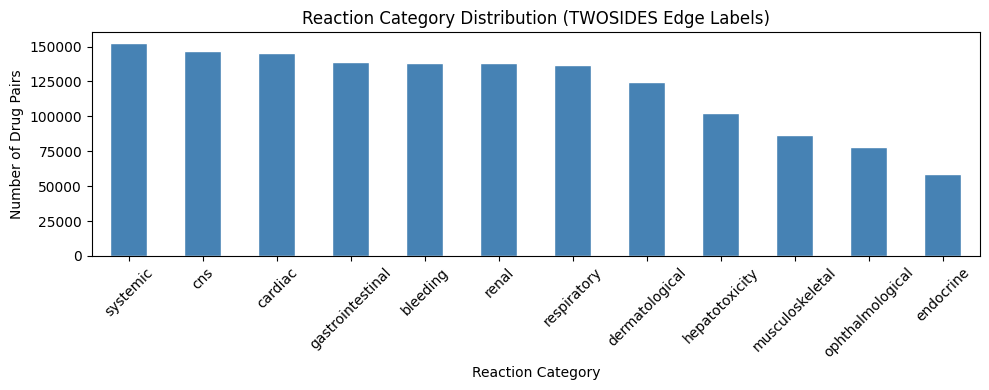

reaction_category
systemic            152601
cns                 146860
cardiac             145423
gastrointestinal    138629
bleeding            138604
renal               138595
respiratory         137144
dermatological      124951
hepatotoxicity      102750
musculoskeletal      86889
ophthalmological     77836
endocrine            58347
Name: count, dtype: int64
Working sample size: 100,000


In [11]:
# Plot reaction category distribution
fig, ax = plt.subplots(figsize=(10, 4))
counts = df['reaction_category'].value_counts()
counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Reaction Category Distribution (TWOSIDES Edge Labels)')
ax.set_xlabel('Reaction Category')
ax.set_ylabel('Number of Drug Pairs')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(counts)

# Sample before building feature matrix to save memory
df_sample = df.sample(n=min(SAMPLE_SIZE * 2, len(df)), random_state=RANDOM_SEED)
del df
gc.collect()
print(f'Working sample size: {len(df_sample):,}')

## Step 2 — Load ChemBERTa Embeddings

In [12]:
emb_df = pd.read_csv('data/chembert_embeddings.csv', index_col='drugbank_id')

print(f'Drugs with embeddings: {len(emb_df):,}')
print(f'Embedding dimensions:  {emb_df.shape[1]}')
emb_df.head(2)

Drugs with embeddings: 14,627
Embedding dimensions:  768


,0,1,2,3,4,5,6,7,8,9,...,758,759,760,761,762,763,764,765,766,767
drugbank_id,,,,,,,,,,,,,,,,,,,,,
DB00006,0.123676,-0.116291,-0.324462,-0.186317,-0.018497,-0.579877,-0.521397,-0.466236,-0.930970,-0.469879,...,-0.470685,0.193103,-0.318010,-0.918129,-0.125753,0.567494,-0.511949,-0.366461,-0.323019,0.236428
DB00014,0.273169,0.120439,-0.304858,-0.496637,0.184836,-0.340423,-0.472996,-0.138943,-0.882995,-0.436192,...,-0.304987,0.092227,-0.121742,-0.813040,-0.417514,0.350035,-0.534993,-0.158482,-0.490144,0.175489


## Step 3 — Build Drug Pair Feature Vectors

For each row in the edge labels table, we construct a single feature vector by **concatenating**:
- ChemBERTa embedding of drug 1 (768 dims)
- ChemBERTa embedding of drug 2 (768 dims)
- PRR_max signal strength (1 dim)

→ **1537-dimensional feature vector per drug pair**

In [13]:
emb_matrix = emb_df.to_numpy()
emb_index  = {drug_id: idx for idx, drug_id in enumerate(emb_df.index)}

X_rows = []
y_rows = []
skipped = 0

for _, row in df_sample.iterrows():
    d1 = row['drug_1_drugbank_id']
    d2 = row['drug_2_drugbank_id']
    if d1 not in emb_index or d2 not in emb_index:
        skipped += 1
        continue
    emb1 = emb_matrix[emb_index[d1]]
    emb2 = emb_matrix[emb_index[d2]]
    prr  = np.array([row['PRR_max']])
    X_rows.append(np.concatenate([emb1, emb2, prr]))
    y_rows.append(row['reaction_category'])

# ── Sample AFTER the loop ──
if len(X_rows) > SAMPLE_SIZE:
    indices = np.random.RandomState(RANDOM_SEED).choice(len(X_rows), SAMPLE_SIZE, replace=False)
    X = np.array(X_rows)[indices]
    y = np.array(y_rows)[indices]
else:
    X = np.array(X_rows)
    y = np.array(y_rows)

del df_sample, emb_matrix
gc.collect()

print(f'Feature matrix shape:         {X.shape}')
print(f'Skipped (missing embeddings): {skipped:,}')

# Encode string labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'\nClasses ({len(le.classes_)}): {le.classes_.tolist()}')

Feature matrix shape:         (50000, 1537)
Skipped (missing embeddings): 14,693

Classes (12): ['bleeding', 'cardiac', 'cns', 'dermatological', 'endocrine', 'gastrointestinal', 'hepatotoxicity', 'musculoskeletal', 'ophthalmological', 'renal', 'respiratory', 'systemic']


## Step 4 — Train / Test Split

80/20 split, stratified to preserve class proportions across both sets.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f'Training samples: {X_train.shape[0]:,}')
print(f'Test samples:     {X_test.shape[0]:,}')

Training samples: 40,000
Test samples:     10,000


## Step 5 — Train Naive Bayes

We use **Gaussian Naive Bayes** which assumes each feature follows a normal distribution. This is appropriate for continuous embedding values.

Naive Bayes is extremely fast even on millions of rows because it only needs to compute per-class means and variances during training — no iterative optimisation required.

Note: StandardScaler is included in the pipeline for consistency with other baseline models, though Naive Bayes is less sensitive to scaling than distance-based methods.

In [15]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

print('Training Naive Bayes...')
pipeline.fit(X_train, y_train)
print('Training complete.')

y_pred = pipeline.predict(X_test)

acc         = accuracy_score(y_test, y_pred)
f1_macro    = f1_score(y_test, y_pred, average='macro')
f1_weighted = f1_score(y_test, y_pred, average='weighted')

print(f'\nAccuracy:      {acc:.4f}')
print(f'F1 (macro):    {f1_macro:.4f}')
print(f'F1 (weighted): {f1_weighted:.4f}')

Training Naive Bayes...
Training complete.

Accuracy:      0.0785
F1 (macro):    0.0644
F1 (weighted): 0.0651


## Step 6 — Per-Class Report

In [16]:
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

                  precision    recall  f1-score   support

        bleeding       0.10      0.09      0.09       969
         cardiac       0.11      0.11      0.11       997
             cns       0.11      0.02      0.04       996
  dermatological       0.00      0.00      0.00       854
       endocrine       0.05      0.07      0.05       426
gastrointestinal       0.08      0.04      0.05       947
  hepatotoxicity       0.07      0.06      0.06       709
 musculoskeletal       0.08      0.03      0.04       609
ophthalmological       0.06      0.45      0.11       564
           renal       0.09      0.06      0.07       972
     respiratory       0.13      0.02      0.03       926
        systemic       0.11      0.10      0.11      1031

        accuracy                           0.08     10000
       macro avg       0.08      0.09      0.06     10000
    weighted avg       0.08      0.08      0.07     10000



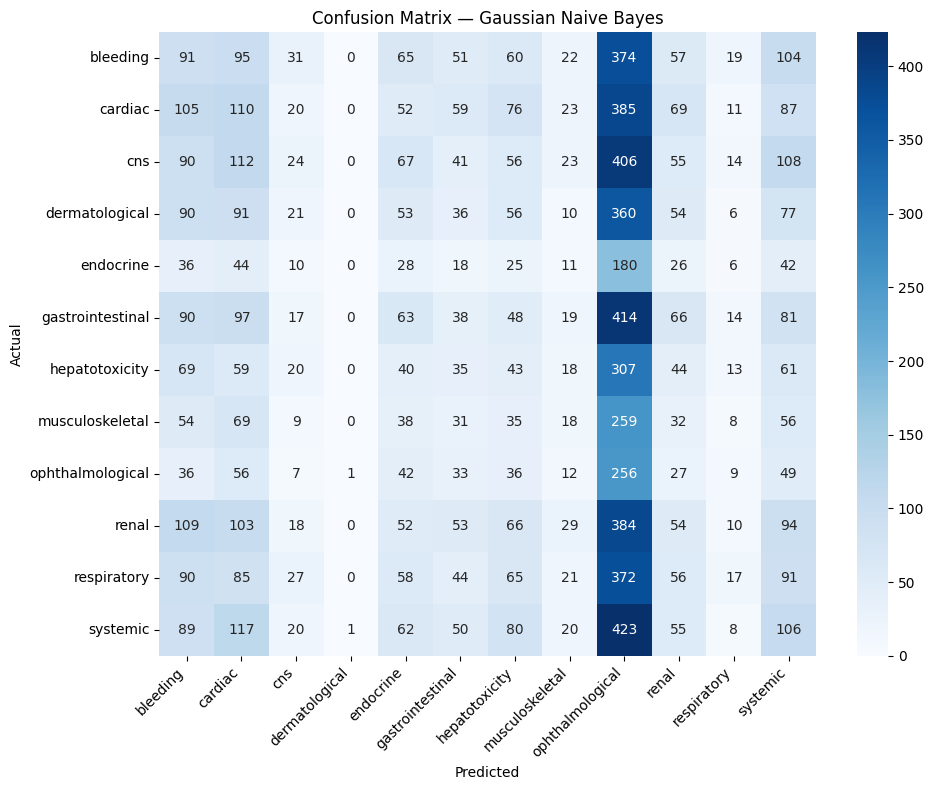

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True, fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues', ax=ax
)
ax.set_title('Confusion Matrix — Gaussian Naive Bayes')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Step 7 — 5-Fold Cross-Validation

Averages performance across 5 different splits to give a more reliable estimate of generalisation.

Running 5-fold cross-validation...
CV F1 scores (5 folds): [0.0695 0.0681 0.0674 0.0686 0.0677]
Mean ± Std:             0.0682 ± 0.0007


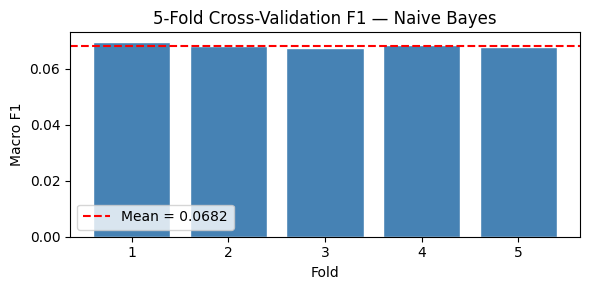

In [18]:
print('Running 5-fold cross-validation...')

cv_scores = cross_val_score(
    pipeline,
    X_train, y_train,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

print(f'CV F1 scores (5 folds): {cv_scores.round(4)}')
print(f'Mean ± Std:             {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

# Plot CV scores
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
ax.set_title('5-Fold Cross-Validation F1 — Naive Bayes')
ax.set_xlabel('Fold')
ax.set_ylabel('Macro F1')
ax.legend()
plt.tight_layout()
plt.show()

## Step 8 — Summary

In [19]:
summary = pd.DataFrame([{
    'Model':         'Naive Bayes (Gaussian)',
    'Accuracy':      round(acc, 4),
    'F1 (macro)':    round(f1_macro, 4),
    'F1 (weighted)': round(f1_weighted, 4),
    'CV F1 Mean':    round(cv_scores.mean(), 4),
    'CV F1 Std':     round(cv_scores.std(), 4),
}])

display(summary)

summary.to_csv('data/naive_bayes_results.csv', index=False)
print('Results saved to data/naive_bayes_results.csv')
print(f'\nGNN target: F1 > 0.75  (Naive Bayes = {f1_macro:.4f})')

,Model,Accuracy,F1 (macro),F1 (weighted),CV F1 Mean,CV F1 Std
0,Naive Bayes (Gaussian),0.0785,0.0644,0.0651,0.0682,0.0007


Results saved to data/naive_bayes_results.csv

GNN target: F1 > 0.75  (Naive Bayes = 0.0644)
